# Inverse design optimization of a compact grating coupler

**This notebook contains a long optimization. Running the entire notebook will cost about 10 FlexCredits and take a few hours.**

The ability to couple light in and out of photonic integrated circuits (PICs) is crucial for developing wafer-scale systems and tests. This need makes designing efficient and compact grating couplers an important task in the PIC development cycle. In this notebook, we will demonstrate how to use `tidy3d` to perform the inverse design of a compact 3D grating coupler. We will show how to improve design fabricability by enhancing permittivity binarization and controlling the device's minimum feature size.

<img src="img/adjoint_6.png" width=400 alt="Schematic of the grating coupler">

In addition, if you are interested in more conventional designs, we modeled an [uniform grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/) and a [Focusing apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) in previous case studies. For more integrated photonic examples, please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/). If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. FDTD simulations can diverge due to various reasons. If you run into any simulation divergence issues, please follow the steps outlined in our [troubleshooting guide](https://www.flexcompute.com/tidy3d/examples/notebooks/DivergedFDTDSimulation/) to resolve it.

We start by importing our typical python packages, plus `autograd` and `tidy3d`.

In [27]:
# Standard python imports.
from typing import List

# Import autograd to be able to use automatic differentiation.
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

## Ian's Notes

Each iteration runs the simulation one time. Each iteration works as follows
1. Compute J(p) and dJ/dp
2. update p = p + (a)dJ/dp
3. run simulation again to compute J(p) and dJ/dp 

The objective function does the following in order
1. creates a simulation with the design region parameters at some p
2. runs the simulation and then calculates the FOM(figure of merit)
3. Subtracts the feature size penalty from the FOM and returns the value for J of that simulation

You pass this objective function into the value_and_grad function from the autograd function and that will calculate both your J(p) and the dJ/dp

## Grating Coupler Inverse Design Configuration

The grating coupler inverse design begins with a rectangular design region connected to a $Si$ waveguide. Throughout the optimization process, this initial structure evolves to convert a vertically incident Gaussian-like mode from an optical fiber into a guided mode and then funnel it into the $Si$ waveguide.

We are considering a full-etched grating structure, so a $SiO_{2}$ BOX layer is included. To reduce backreflection, we adjusted the fiber tilt angle to $10^{\circ}$ [[1](https://doi.org/10.1364/OE.23.022628), [2](https://doi.org/10.3390/mi11070666)].

In the following block of code, you can find the parameters that can be modified to configure the grating coupler structure, optimization, and simulation setup. Special care should be devoted to the `it_per_step` and `opt_steps` variables below.

In [3]:
# Geometric parameters.
w_thick = 0.22  # Waveguide thickness (um).
w_width = 0.5  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
box_thick = 0.752  # SiO2 BOX thickness (um).
spot_size = 1.5  # Spot size of the input Gaussian field regarding a lensed fiber (um).
fiber_tilt = 10.0  # Fiber tilt angle in xz plane (degrees).
yz_tilt = 1.432  # Additional tilt in yz plane (degrees); applied as +/- for top/bottom source.
src_offset = 0.05  # Distance between the source focus and device (um).

# Material.
nSi = 3.695  # Silicon refractive index.
nSiO2 = 1.44  # Silica refractive index.
nSi3N4 = 2.03

# Design region parameters.
gc_width = 4.0  # Grating coupler width per channel (um).
gc_width_total = 2 * gc_width  # Total y-extent covering both channels (um).
gc_length = 4.0  # Grating coupler length (um).
dr_grid_size = 0.02  # Grid size within the design region (um).

# Inverse design setup parameters.
#################################################################
# Total number of iterations = opt_steps x it_per_step.
it_per_step = 1  # Number of iterations per optimization step.
opt_steps = 25  # Number of optimization steps.
#################################################################
eta = 0.50  # Threshold value for the projection filter.
fom_name_top = "fom_top"  # Monitor name for the top (positive-y) channel.
fom_name_bot = "fom_bot"  # Monitor name for the bottom (negative-y) channel.

# Simulation wavelength.
wl = 0.729  # Central simulation wavelength (um).
bw = 0.02  # Simulation bandwidth (um).
n_wl = 10  # Number of wavelength points within the bandwidth.

# feature size
min_feature_size = 0.060
filter_radius = min_feature_size

# Buffer layer thickness
border_buffer = 0.16

# projection
beta_min = 1.0
beta_max = 30.0


In [4]:
total_iter = opt_steps * it_per_step
print(f"Total iterations = {total_iter}")

Total iterations = 25


## Inverse Design Optimization Set Up

We will calculate the values of some parameters used throughout the inverse design set up.

In [5]:
# Minimum and maximum values for the permittivities.
eps_max = nSi3N4**2
eps_min = 1.0
eps_si = nSi**2

# Material definitions.
mat_si = td.Medium(permittivity=eps_si)  # Si bottom layer material.
mat_sio2 = td.Medium(permittivity=nSiO2**2)  # BOX material.
mat_si3n4 = td.Medium(permittivity=eps_max)  # Waveguide material.

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 5e-12

# Channel y-centers (top = +y, bottom = -y).
y_center_top = gc_width / 2    # +2.0 um
y_center_bot = -gc_width / 2   # -2.0 um

# Combined source angles: xz tilt (fiber_tilt) + yz tilt (yz_tilt).
# In tidy3d spherical coords: theta from z-axis, phi azimuthal in xy-plane.
xz_rad = fiber_tilt * np.pi / 180.0
yz_rad = yz_tilt * np.pi / 180.0
theta_src = float(np.arcsin(np.sqrt(np.sin(xz_rad)**2 + np.sin(yz_rad)**2)))
phi_top = float(np.arctan2(np.sin(yz_rad), np.sin(xz_rad)))   # +yz tilt for top source
phi_bot = -phi_top                                             # -yz tilt for bottom source

# Computational domain size.
pml_spacing = 0.6 * wl
size_x = pml_spacing + w_length + gc_length + 2 * border_buffer
size_y = gc_width_total + 2 * pml_spacing + 2 * border_buffer  # doubled y-extent
size_z = w_thick + box_thick + 2 * pml_spacing
center_z = size_z / 2 - pml_spacing - w_thick / 2
eff_inf = 1000

# Inverse design variables.
src_pos_z = w_thick / 2 + src_offset
mon_pos_x = -size_x / 2 + 0.25 * wl
mon_w = int(3 * w_width / dr_grid_size) * dr_grid_size
mon_h = int(5 * w_thick / dr_grid_size) * dr_grid_size
nx = int((gc_length + 2 * border_buffer) / dr_grid_size)
# Full y-range stored (no symmetry folding): gc_width_total + 2*border_buffer.
ny = int((gc_width_total + 2 * border_buffer) / dr_grid_size)
npar = int(nx * ny)
dr_size_x = nx * dr_grid_size
dr_size_y = ny * dr_grid_size  # full y-range
dr_center_x = -size_x / 2 + w_length + dr_size_x / 2
n_border = int(border_buffer / dr_grid_size)

# Y-indices of waveguide connection points within the design parameter array.
# coords_y goes from -dr_size_y/2 to +dr_size_y/2.
n_wg_half = int((w_width / 2) / dr_grid_size)
n_y_center_top = int((y_center_top + dr_size_y / 2) / dr_grid_size)
n_y_center_bot = int((y_center_bot + dr_size_y / 2) / dr_grid_size)


First, we will introduce the simulation components that do not change during optimization, such as the $Si$ waveguide and $SiO_{2}$ BOX layer. Additionally, we will include a Gaussian source to drive the simulations, and a mode monitor to compute the objective function.

In [6]:
# Top waveguide (positive y channel).
waveguide_top = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, y_center_top - w_width / 2, -w_thick / 2),
        rmax=(-size_x / 2 + w_length, y_center_top + w_width / 2, w_thick / 2),
    ),
    medium=mat_si3n4,
)

# Bottom waveguide (negative y channel).
waveguide_bot = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, y_center_bot - w_width / 2, -w_thick / 2),
        rmax=(-size_x / 2 + w_length, y_center_bot + w_width / 2, w_thick / 2),
    ),
    medium=mat_si3n4,
)

# SiO2 BOX layer.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -w_thick / 2 - box_thick),
        rmax=(eff_inf, eff_inf, -w_thick / 2),
    ),
    medium=mat_sio2,
)

# Si3N4 substrate.
si_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=(eff_inf, eff_inf, -w_thick / 2 - box_thick),
    ),
    medium=mat_si3n4,
)

# Top Gaussian source: xz tilt + positive yz tilt, centered at top channel.
gauss_top = td.GaussianBeam(
    center=(dr_center_x, y_center_top, src_pos_z),
    size=(dr_size_x - 2 * border_buffer, gc_width - 2 * border_buffer, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    pol_angle=np.pi / 2,
    angle_theta=theta_src,
    angle_phi=phi_top,
    direction="-",
    num_freqs=7,
    waist_radius=spot_size / 2,
)

# Bottom Gaussian source: xz tilt + negative yz tilt, centered at bottom channel.
gauss_bot = td.GaussianBeam(
    center=(dr_center_x, y_center_bot, src_pos_z),
    size=(dr_size_x - 2 * border_buffer, gc_width - 2 * border_buffer, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    pol_angle=np.pi / 2,
    angle_theta=theta_src,
    angle_phi=phi_bot,
    direction="-",
    num_freqs=7,
    waist_radius=spot_size / 2,
)

# Mode spec shared by both monitors.
mode_spec = td.ModeSpec(num_modes=1, target_neff=nSi3N4)

# Top mode monitor at the top waveguide input face.
fom_monitor_top = td.ModeMonitor(
    center=[mon_pos_x, y_center_top, 0],
    size=[0, mon_w, mon_h],
    freqs=[freq],
    mode_spec=mode_spec,
    name=fom_name_top,
)

# Bottom mode monitor at the bottom waveguide input face.
fom_monitor_bot = td.ModeMonitor(
    center=[mon_pos_x, y_center_bot, 0],
    size=[0, mon_w, mon_h],
    freqs=[freq],
    mode_spec=mode_spec,
    name=fom_name_bot,
)


Now, we will define a random vector of initial design parameters or load a previously designed structure.

> Note: if a previous optimization file is found, the optimizer will pick up where that left off instead.

In [7]:
init_par = np.random.uniform(0, 1, int(npar))
init_par = sp.ndimage.gaussian_filter(init_par, 1)
init_par = init_par.reshape((nx, ny))

### Fabrication Constraints

We will use the `tidy3d.plugins.autograd` plugin to introduce functions that improve device fabricability. A classical conic density filter, which is popular in topology optimization problems, is used to enforce a minimum feature size specified by the `filter_radius` variable. Next, a hyperbolic tangent projection function is applied to eliminate grayscale and obtain a binarized permittivity pattern. The `beta` parameter controls the sharpness of the transition in the projection function, and for better results, this parameter should be gradually increased throughout the optimization process. Finally, the design parameters are transformed into permittivity values. For a detailed review of these methods, refer to [[3](https://doi.org/10.1007/s00419-015-1106-4)].

We will also introduce a buffer layer around the design region to enhance fabricability at the interfaces. The permittivity is enforced to lower values within the buffer layer, except at the output waveguide connection where we want a smooth transition.

In [8]:
def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities after applying a conic density filter on design parameters
    to enforce fabrication constraints, followed by a binarization projection function
    which reduces grayscale.
    Parameters:
        design_param: np.ndarray
            Vector of design parameters.
        beta: float = 1.0
            Sharpness parameter for the projection filter.
        binarize: bool = False
            Enforce binarization.
    Returns:
        eps: np.ndarray
            Permittivity vector.
    """

    # Calculates the permittivities from the transformed design parameters.
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps

In [9]:
from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")


def interface_buffer(params):
    """Force full material at both waveguide connection slots; leave rest of params unchanged."""
    mask = np.zeros_like(params)  # plain numpy — mask is not differentiated
    # Open connection for the top waveguide (positive-y channel).
    mask[0:n_border, n_y_center_top - n_wg_half : n_y_center_top + n_wg_half + 1] = 1
    # Open connection for the bottom waveguide (negative-y channel).
    mask[0:n_border, n_y_center_bot - n_wg_half : n_y_center_bot + n_wg_half + 1] = 1
    return params * (1 - mask) + mask


def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3


def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values


The permittivity values obtained from the design parameters are then used to build a [CustomMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomMedium.html). As we will consider symmetry about the x-axis in the simulations, only the upper-half part of the design region needs to be populated. A `Structure` built using the `CustomMedium` will be returned by the following function: 

In [10]:
def update_design(eps) -> List[td.Structure]:
    """Build the design region CustomMedium from the full-y-range permittivity array."""
    eps_val = anp.array(eps).reshape((nx, ny, 1))

    # coords_y spans the full design region from -dr_size_y/2 to +dr_size_y/2.
    coords_x = [(dr_center_x - dr_size_x / 2) + ix * dr_grid_size for ix in range(nx)]
    coords_y = [(-dr_size_y / 2) + iy * dr_grid_size for iy in range(ny)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]


Next, we will write a function to return the `td.Simulation` object. Note that we are using a `MeshOverrideStructure` to obtain a uniform mesh over the design region.

In [11]:
def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    source: str = 'top',
    binarize: bool = False,
) -> td.Simulation:
    """Build the adjoint simulation for one channel at a time.

    Parameters
    ----------
    source : 'top' or 'bot'
        Which channel's source and monitor to include. Each channel is run
        as a separate simulation so their gradients can be summed cleanly.
    """
    eps = get_eps(design_param, beta, binarize)
    design_structure = update_design(eps)

    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, w_thick)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    if source == 'top':
        src = gauss_top
        mon = fom_monitor_top
    else:
        src = gauss_bot
        mon = fom_monitor_bot

    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=15,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, 0, 0),  # No y-symmetry: sources are not mirror images of each other.
        structures=[waveguide_top, waveguide_bot, sio2_substrate, si_substrate] + design_structure,
        sources=[src],
        monitors=[mon],
        run_time=run_time,
        subpixel=True,
    )


Let's visualize the simulation set up and verify if all the elements are in their correct places.

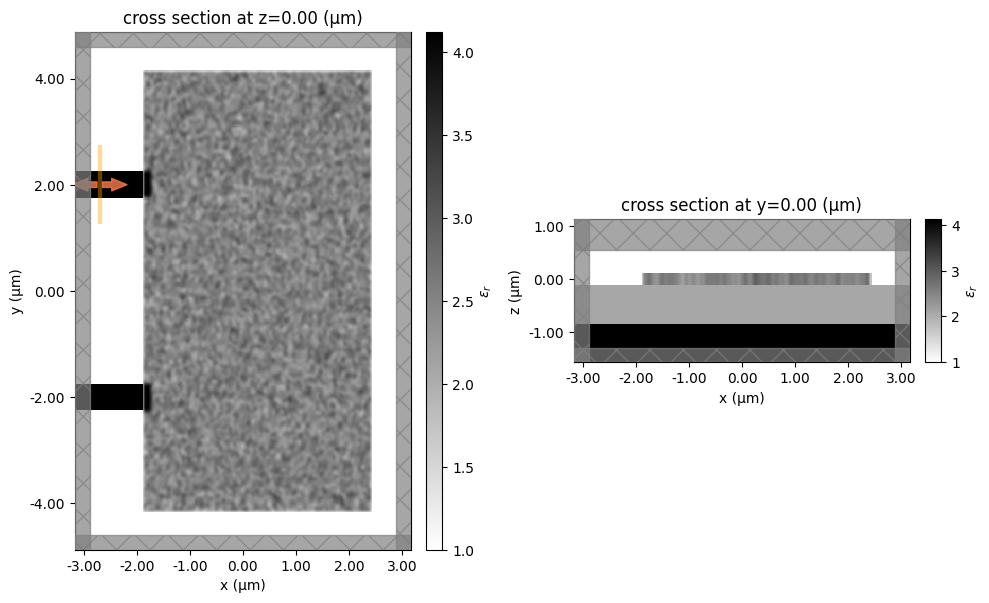

In [12]:
init_design = make_adjoint_sim(init_par, beta=beta_min, source='top')

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 10))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
plt.show()
init_design.plot_3d()


In [13]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)


def fom(sim_data: td.SimulationData, monitor_name: str) -> float:
    """Return the power coupled into mode 0 at the given monitor."""
    output_amps = sim_data[monitor_name].amps
    amp = output_amps.sel(direction="-", f=freq, mode_index=0).values
    return anp.sum(anp.abs(amp) ** 2)


def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    params_processed = pre_process(params, beta=beta)
    return erode_dilate_penalty(params_processed)


def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    """Objective function: sum of coupling efficiency for top and bottom channels.

    Runs two separate simulations (one per source/monitor pair) so that autograd
    can compute dJ_top/dp and dJ_bot/dp independently and sum them into the total
    gradient dJ/dp used by the optimizer.
    """
    suffix = f"_step_{step_num}" if step_num is not None else ""

    # --- Top channel ---
    sim_top = make_adjoint_sim(design_param, beta, source='top')
    data_top = web.run(sim_top, task_name=f"inv_des_top{suffix}", verbose=verbose)
    J_top = fom(data_top, fom_name_top)

    # --- Bottom channel ---
    sim_bot = make_adjoint_sim(design_param, beta, source='bot')
    data_bot = web.run(sim_bot, task_name=f"inv_des_bot{suffix}", verbose=verbose)
    J_bot = fom(data_bot, fom_name_bot)

    feature_size_penalty = penalty(design_param, beta=beta)
    J = (J_top + J_bot) - feature_size_penalty
    return J


obj_grad = value_and_grad(obj)


## Optimization

We need to provide an objective function and its gradients with respect to the design parameters of the optimization algorithm.

Our figure-of-merit (FOM) is the coupling efficiency of the incident power into the fundamental transverse electric mode of the $Si$ waveguide. The optimization algorithm will call the objective function at each iteration step. Therefore, the objective function will create the adjoint simulation, run it, and return the FOM value.

Next we will define the optimizer using `optax`. We will save the optimization progress in a `pickle` file. If that file is found, it will pick up the optimization from the last state. Otherwise, we will create a blank history.

In [14]:
import pickle

import optax

# hyperparameters
learning_rate = 0.2
optimizer = optax.adam(learning_rate=learning_rate)

# where to store history
history_fname = "misc/grating_coupler_history_2input.pkl"


def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict


### Checking For a Previous Optimization

If `history_fname` is a valid file, the results of a previous optimization are loaded, then the optimization will continue from the last iteration step. If the optimization was completed, only the final structure will be simulated. The pickle file used in this notebook can be downloaded from our documentation [repo](https://github.com/flexcompute/tidy3d-notebooks/tree/develop/misc).

In [15]:
try:
    history_dict = load_history()
    opt_state = history_dict["opt_states"][-1]
    params = history_dict["params"][-1]
    num_iters_completed = len(history_dict["params"])
    print("Loaded optimization checkpoint from file.")
    print(f"Found {num_iters_completed} iterations previously completed out of {total_iter} total.")
    if num_iters_completed < total_iter:
        print("Will resume optimization.")
    else:
        print("Optimization completed, will return results.")

except FileNotFoundError:
    params = np.array(init_par)
    opt_state = optimizer.init(params)
    history_dict = dict(
        values=[],
        params=[],
        gradients=[],
        opt_states=[opt_state],
        data=[],
        beta=[],
    )

Loaded optimization checkpoint from file.
Found 25 iterations previously completed out of 25 total.
Optimization completed, will return results.


In [16]:
iter_done = len(history_dict["values"])

for i in range(iter_done, total_iter):
    print(f"iteration = ({i + 1} / {total_iter})")

    # compute gradient and current objective function value
    perc_done = i / (total_iter - 1)
    #beta_i = beta_min * (1 - perc_done) + beta_max * perc_done
    beta_i = beta_min
    value, gradient = obj_grad(params, beta=beta_min) #binarization turned off for now

    #sim_data_i = latest_sim_data

    # outputs
    print(f"\tbeta = {beta_i}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = optax.apply_updates(params, updates)

    # cap parameters between 0 and 1
    np.clip(params, 0.0, 1.0, out=params)

    # save history
    history_dict["values"].append(value)
    history_dict["params"].append(params)
    history_dict["beta"].append(beta_i)
    history_dict["gradients"].append(gradient)
    history_dict["opt_states"].append(opt_state)
    #history_dict["data"].append(sim_data_i) # uncomment to store data, can create large files
    save_history(history_dict)

### Optimization Results

After 150 iterations, a coupling efficiency value of 0.71 (-1.48 dB) was achieved at the central wavelength.

In [17]:
obj_vals = np.array(history_dict["values"])
final_par = history_dict["params"][-1]
final_beta = history_dict["beta"][-1]

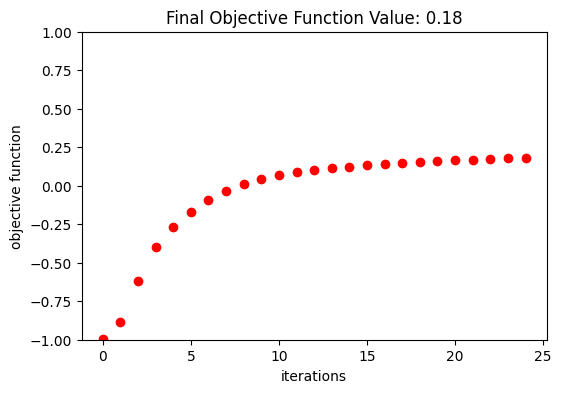

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(obj_vals, "ro")
ax.set_xlabel("iterations")
ax.set_ylabel("objective function")
ax.set_ylim(-1, 1)
ax.set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

The final grating coupler structure is well binarized, with mostly black (`eps_max`) and white (`eps_min`) regions.

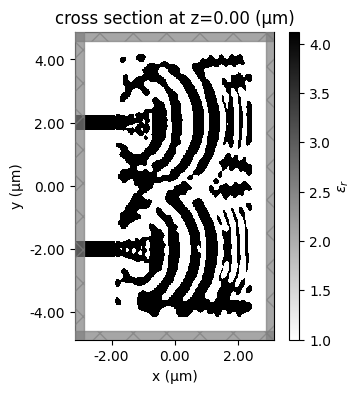

In [19]:
fig, ax = plt.subplots(1, figsize=(4, 4))
sim_final = make_adjoint_sim(final_par, beta=final_beta, source='top', binarize=True)
sim_final.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax)
plt.show()


Once the inverse design is complete, we can visualize the field distributions and the wavelength dependent coupling efficiency.

In [20]:
# Field monitors to visualize the final fields.
field_xy = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_xy",
)

field_xz = td.FieldMonitor(
    size=(td.inf, 0, td.inf),
    freqs=[freq],
    name="field_xz",
)

# Broadband efficiency monitors for both channels.
gc_efficiency_top = td.ModeMonitor(
    center=[mon_pos_x, y_center_top, 0],
    size=[0, mon_w, mon_h],
    freqs=freqs,
    mode_spec=mode_spec,
    name="gc_efficiency_top",
)

gc_efficiency_bot = td.ModeMonitor(
    center=[mon_pos_x, y_center_bot, 0],
    size=[0, mon_w, mon_h],
    freqs=freqs,
    mode_spec=mode_spec,
    name="gc_efficiency_bot",
)

# Run the top-channel final sim (source = top fiber).
sim_final_top = make_adjoint_sim(final_par, beta=final_beta, source='top', binarize=True)
sim_final_top = sim_final_top.copy(
    update=dict(monitors=(field_xy, field_xz, gc_efficiency_top, gc_efficiency_bot))
)
job_top = web.Job(simulation=sim_final_top, task_name="inv_des_final_top")
estimated_cost_top = web.estimate_cost(job_top.task_id)
print(f"Estimated cost (top final): {estimated_cost_top} FlexCredits")

# Run the bottom-channel final sim (source = bottom fiber).
sim_final_bot = make_adjoint_sim(final_par, beta=final_beta, source='bot', binarize=True)
sim_final_bot = sim_final_bot.copy(
    update=dict(monitors=(field_xy, field_xz, gc_efficiency_top, gc_efficiency_bot))
)
job_bot = web.Job(simulation=sim_final_bot, task_name="inv_des_final_bot")
estimated_cost_bot = web.estimate_cost(job_bot.task_id)
print(f"Estimated cost (bot final): {estimated_cost_bot} FlexCredits")

# Submit both jobs to the cloud simultaneously, then wait for results.
job_top.start()
job_bot.start()
sim_data_final_top = job_top.load(path="data/sim_final_top.hdf5")
sim_data_final_bot = job_bot.load(path="data/sim_final_bot.hdf5")


12:20:47 PDT Created task 'inv_des_final_top' with resource_id                  
             'fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=337965;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=229566;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\taskId]8;;\]8;id=337965;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\=]8;;\]8;id=291628;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\fdve]8;;\]8;id=337965;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\-577d76fb-0f1]8;;\
             ]8;id=337965;https://tidy3d.simulation.cloud/workbench?taskId=fdve-577d76fb-0f1a-4543-b24d-de3f90264c2c\a-4543-b24d-de3f90264c2c']8;;\.

             Task folder: ]8;id=357198;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

12:20:48 PDT Estimated FlexCredit cost: 0.542. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Estimated cost (bot final): 0.5418586840354268 FlexCredits


Output()

12:20:52 PDT Loading simulation from data/sim_final_top.hdf5

Output()

12:20:53 PDT Loading simulation from data/sim_final_bot.hdf5

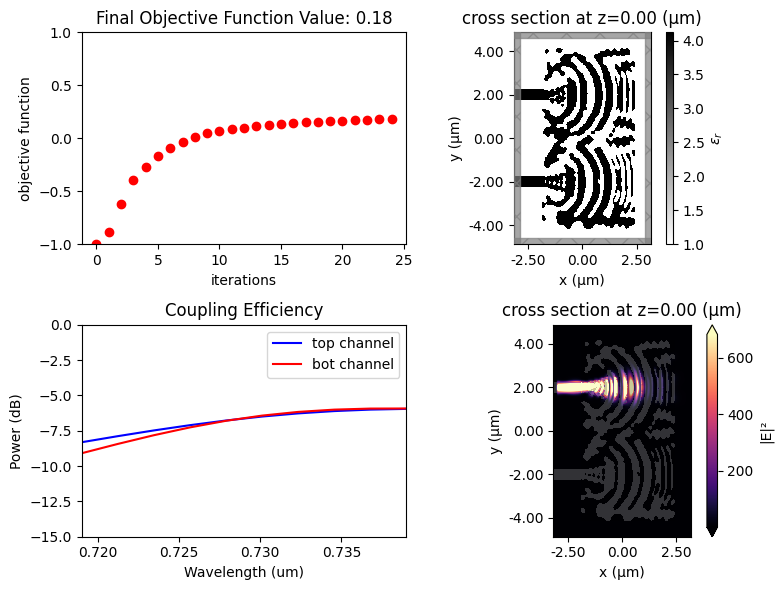

In [21]:
def get_efficiency_db(sim_data, monitor_name):
    mode_amps = sim_data[monitor_name]
    coeffs_f = mode_amps.amps.sel(direction="-")
    power = np.abs(coeffs_f.sel(mode_index=0)) ** 2
    return 10 * np.log10(power)


power_top_db = get_efficiency_db(sim_data_final_top, "gc_efficiency_top")
power_bot_db = get_efficiency_db(sim_data_final_bot, "gc_efficiency_bot")

sim_plot = sim_final_top.updated_copy(symmetry=(0, 0, 0), monitors=(field_xy, field_xz, gc_efficiency_top, gc_efficiency_bot))
sim_data_plot = sim_data_final_top.updated_copy(simulation=sim_plot) #change this from sim_data_final_bot to sim_data_final_top so simulation cell shows either one

f, ax = plt.subplots(2, 2, figsize=(8, 6), tight_layout=True)
sim_plot.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax[0, 1])

ax[1, 0].plot(wl_range, power_top_db, "-b", label="top channel")
ax[1, 0].plot(wl_range, power_bot_db, "-r", label="bot channel")
ax[1, 0].set_xlabel("Wavelength (um)")
ax[1, 0].set_ylabel("Power (dB)")
ax[1, 0].set_ylim(-15, 0)
ax[1, 0].set_xlim(wl - bw / 2, wl + bw / 2)
ax[1, 0].set_title("Coupling Efficiency")
ax[1, 0].legend()

sim_data_plot.plot_field("field_xy", "E", "abs^2", z=0, ax=ax[1, 1])

ax[0, 0].plot(obj_vals, "ro")
ax[0, 0].set_xlabel("iterations")
ax[0, 0].set_ylabel("objective function")
ax[0, 0].set_ylim(-1, 1)
ax[0, 0].set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()


In [22]:
loss_top_db = float(np.max(power_top_db))
loss_bot_db = float(np.max(power_bot_db))
print(f"Top channel optimized loss: {loss_top_db:.2f} dB")
print(f"Bottom channel optimized loss: {loss_bot_db:.2f} dB")


Top channel optimized loss: -5.95 dB
Bottom channel optimized loss: -5.92 dB


## Far-Field Projection

Using reciprocal excitation: a `ModeSource` is launched from each waveguide port back through the grating. The upward-radiating near field is captured at the source plane and projected to 100 µm using `FieldProjector`.

In [23]:
# --- Reciprocal sim: top channel ---
mode_source_top = td.ModeSource(
    center=gc_efficiency_top.center,
    size=gc_efficiency_top.size,
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq / 10),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)

field_near_top = td.FieldMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_near_top",
)

sim_farfield_top = sim_final_top.copy(
    update=dict(
        sources=[mode_source_top],
        monitors=[field_near_top],
    )
)

job_ff_top = web.Job(simulation=sim_farfield_top, task_name="farfield_top")
print(f"Estimated cost (top far-field): {web.estimate_cost(job_ff_top.task_id)} FlexCredits")
sim_data_ff_top = job_ff_top.run(path="data/farfield_top.hdf5")

12:20:55 PDT Created task 'farfield_top' with resource_id                       
             'fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=58668;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=350706;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\taskId]8;;\]8;id=58668;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\=]8;;\]8;id=135833;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\fdve]8;;\]8;id=58668;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\-8a262309-59b]8;;\
             ]8;id=58668;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8a262309-59b1-42d6-a8a6-ae25e13f51b5\1-42d6-a8a6-ae25e13f51b5']8;;\.

             Task folder: ]8;id=22904;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

             Estimated FlexCredit cost: 0.536. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

12:20:56 PDT Estimated FlexCredit cost: 0.536. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Estimated cost (top far-field): 0.5355005221528193 FlexCredits


             status = success

Output()

12:20:57 PDT Loading simulation from data/farfield_top.hdf5

In [24]:
# --- Reciprocal sim: bottom channel ---
mode_source_bot = td.ModeSource(
    center=gc_efficiency_bot.center,
    size=gc_efficiency_bot.size,
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq / 10),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)

field_near_bot = td.FieldMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="field_near_bot",
)

sim_farfield_bot = sim_final_bot.copy(
    update=dict(
        sources=[mode_source_bot],
        monitors=[field_near_bot],
    )
)

job_ff_bot = web.Job(simulation=sim_farfield_bot, task_name="farfield_bot")
print(f"Estimated cost (bot far-field): {web.estimate_cost(job_ff_bot.task_id)} FlexCredits")
sim_data_ff_bot = job_ff_bot.run(path="data/farfield_bot.hdf5")

12:20:58 PDT Created task 'farfield_bot' with resource_id                       
             'fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=662839;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=252233;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\taskId]8;;\]8;id=662839;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\=]8;;\]8;id=730223;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\fdve]8;;\]8;id=662839;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\-e37e6278-ee4]8;;\
             ]8;id=662839;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e37e6278-ee41-48fc-b22f-98e503cb30f4\1-48fc-b22f-98e503cb30f4']8;;\.

             Task folder: ]8;id=357345;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

12:20:59 PDT Estimated FlexCredit cost: 0.536. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             Estimated FlexCredit cost: 0.536. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

Estimated cost (bot far-field): 0.5355005221528193 FlexCredits


12:21:00 PDT status = success

Output()

             Loading simulation from data/farfield_bot.hdf5

In [41]:
# --- Project near fields to 100 um ---
r_proj = 100.0  # projection distance (um)

# Observation grid: span the full grating length in x and both channel beams in y.
# At 100 um distance the yz tilt (~1.43 deg) shifts each beam ~2.5 um in y.
x_proj = np.linspace(0, 50, 100)
y_proj = np.linspace(-30, 25, 150)

monitor_far_top = td.FieldProjectionCartesianMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="far_field_top",
    proj_axis=2,
    x=list(x_proj),
    y=list(y_proj),
    proj_distance=r_proj,
    far_field_approx=True,
)

monitor_far_bot = td.FieldProjectionCartesianMonitor(
    center=(dr_center_x, 0, src_pos_z),
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="far_field_bot",
    proj_axis=2,
    x=list(x_proj),
    y=list(y_proj),
    proj_distance=r_proj,
    far_field_approx=True,
)


def get_proj_fields(sim_data, near_monitor, far_monitor):
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data,
        near_monitors=[near_monitor],
        normal_dirs=["+"],
        pts_per_wavelength=10,
    )
    return projector.project_fields(far_monitor)


proj_top = get_proj_fields(sim_data_ff_top, field_near_top, monitor_far_top)
proj_bot = get_proj_fields(sim_data_ff_bot, field_near_bot, monitor_far_bot)

12:57:21 PDT WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

Output()

12:57:42 PDT WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

Output()

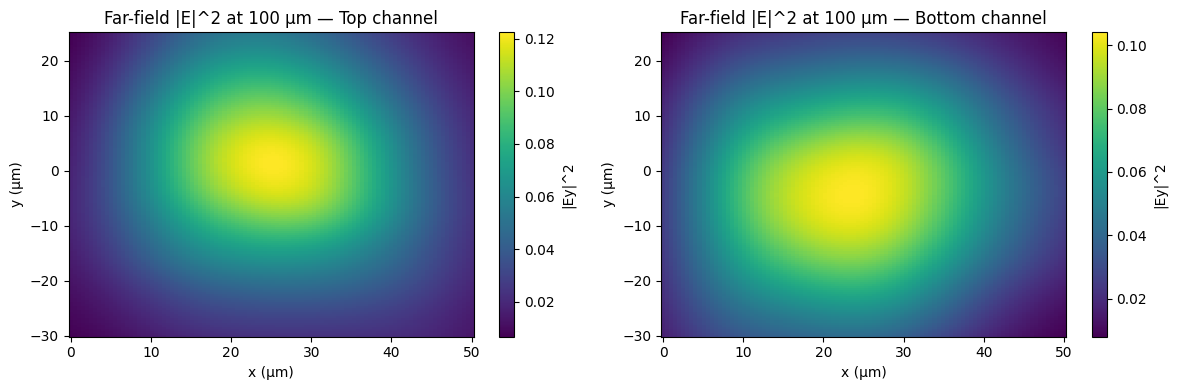

In [43]:
# --- Visualize far-field intensity ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, proj, near_mon, title in zip(
    axes,
    [proj_top, proj_bot],
    [field_near_top, field_near_bot],
    ["Top channel", "Bottom channel"],
):
    Ephi = proj.Ephi.abs.isel(f=0, z=0)
    Etheta = proj.Etheta.abs.isel(f=0, z=0)
    intensity = (np.abs(Ephi.values) ** 2) + (np.abs(Etheta.values) ** 2)
    im = ax.pcolormesh(x_proj, y_proj, intensity.T, shading="auto")
    fig.colorbar(im, ax=ax, label="|Ey|^2")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Far-field |E|^2 at {r_proj:.0f} µm — {title}")

plt.tight_layout()
plt.show()

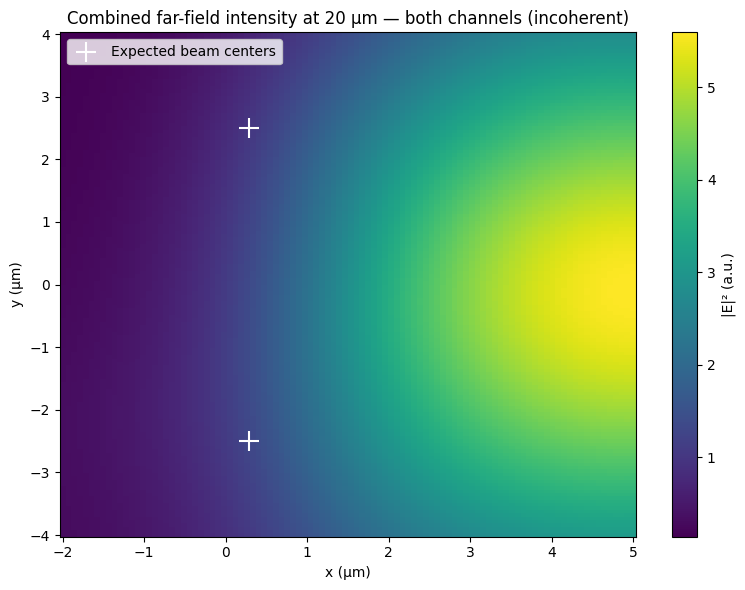

Top beam expected at:    x = 0.3 µm,  y = 2.5 µm
Bottom beam expected at: x = 0.3 µm,  y = -2.5 µm
Beam separation in y:    5.0 µm


In [36]:
# --- Combined far-field: both channels on one plot (incoherent sum) ---
# The two fiber sources are independent, so intensities add (not complex fields).
I_top = np.squeeze(np.abs(proj_top.Etheta.isel(f=0).values)**2 + np.abs(proj_top.Ephi.isel(f=0).values)**2)
I_bot = np.squeeze(np.abs(proj_bot.Etheta.isel(f=0).values)**2 + np.abs(proj_bot.Ephi.isel(f=0).values)**2)
I_combined = I_top + I_bot

# Expected beam center positions from tilt geometry.
x_beam_center = dr_center_x
y_top_expected = y_center_top + (r_proj * np.tan(np.deg2rad(yz_tilt)))
y_bot_expected = y_center_bot - (r_proj * np.tan(np.deg2rad(yz_tilt)))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(x_proj, y_proj, I_combined.T, shading="auto")
fig.colorbar(im, ax=ax, label="|E|² (a.u.)")

ax.scatter(
    [x_beam_center, x_beam_center],
    [y_top_expected, y_bot_expected],
    marker="+", color="white", s=200, linewidths=1.5, zorder=5,
    label=f"Expected beam centers",
)
ax.legend(loc="upper left")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title(f"Combined far-field intensity at {r_proj:.0f} µm — both channels (incoherent)")
plt.tight_layout()
plt.show()

print(f"Top beam expected at:    x = {x_beam_center:.1f} µm,  y = {y_top_expected:.1f} µm")
print(f"Bottom beam expected at: x = {x_beam_center:.1f} µm,  y = {y_bot_expected:.1f} µm")
print(f"Beam separation in y:    {y_top_expected - y_bot_expected:.1f} µm")

## Export to GDS
The `Simulation` object has the [.to_gds_file](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html#tidy3d.Simulation.to_gds_file) convenience function to export the final design to a `GDS` file. In addition to a file name, it is necessary to set a cross-sectional plane (`z = 0` in this case) on which to evaluate the geometry, a `frequency` to evaluate the permittivity, and a `permittivity_threshold` to define the shape boundaries in custom mediums. See the [GDS export](https://www.flexcompute.com/tidy3d/examples/notebooks/GDSExport/) notebook for a detailed example on using `.to_gds_file` and other GDS related functions.

In [ ]:
sim_final.to_gds_file(
    fname="./misc/inverse_designed_gc.gds",
    z=0,
    permittivity_threshold=(eps_max + eps_min) / 2,
    frequency=freq,
)